In [ ]:
https://www.kaggle.com/datasets/parisrohan/credit-score-classification

RICHIESTA: scrivi una funzione python per caricare un file train.csv

FORMATO: restituisci del codice python correttamente formattato

CONTESTO: questo train.csv è un dataset scaricato da kaggle per creare un modello che valuti il credit score

In [1]:
import pandas as pd
import os

def carica_dataset_credit_score(file_path):
    """
    Carica il dataset train.csv e fornisce una panoramica iniziale.
    
    Args:
        file_path (str): Il percorso relativo o assoluto del file .csv
        
    Returns:
        pd.DataFrame: Il dataframe caricato.
    """
    if not os.path.exists(file_path):
        print(f"Errore: Il file '{file_path}' non è stato trovato.")
        return None
    
    try:
        # Caricamento del dataset
        df = pd.read_csv(file_path)
        
        print(f"Dataset caricato con successo!")
        print(f"Dimensioni: {df.shape[0]} righe, {df.shape[1]} colonne")
        print("-" * 30)
        
        return df
        
    except Exception as e:
        print(f"Si è verificato un errore durante il caricamento: {e}")
        return None

# Esempio di utilizzo:
df_train = carica_dataset_credit_score('train.csv')

Dataset caricato con successo!
Dimensioni: 100000 righe, 28 colonne
------------------------------


C:\Users\mbagn\AppData\Local\Temp\ipykernel_29772\922844817.py:20: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path)


VADO A CHIEDERE DI GENERARE UNA LISTA DI STEP E LI ESEGUO UNO ALLA VOLTA

PERSONIFICAZIONE: sei un esperto in machine learning 

RICHIESTA e FORMATO: devo esplorare i dati del mio dataset train.csv, crea una lista di punti da valutare nell'esplorazione dati

CONTESTO: genera questa lista di punti come guida per procedere in un secondo momento con la generazione del codice di ogni punto

Piacere di conoscerti. In qualità di esperto di Machine Learning, posso dirti che la fase di **Exploratory Data Analysis (EDA)** è il momento in cui si vince o si perde una competizione su Kaggle. Per un problema di **Credit Scoring**, dove l'obiettivo è prevedere l'affidabilità creditizia di un cliente, non stiamo solo cercando pattern statistici, ma stiamo cercando segnali di rischio.

Ecco la tua guida strategica per l'esplorazione del dataset `train.csv`.

---

### 1. Panoramica Strutturale e Integrità

Prima di analizzare i numeri, dobbiamo capire con cosa abbiamo a che fare.

* **Ispezione dei Tipi di Dato:** Identificare quali variabili sono numeriche (float/int) e quali categoriche (object/category).
* **Analisi dei Valori Mancanti:** Verificare la percentuale di `NaN` per ogni colonna. Nel credit scoring, dati mancanti sul reddito o sui garanti sono segnali informativi, non solo errori.
* **Verifica Duplicati:** Identificare righe identiche che potrebbero influenzare la validazione del modello.

### 2. Analisi della Target Variable (Sbilanciamento)

Il Credit Scoring è quasi sempre un problema di **classi sbilanciate** (molti pagatori puntuali, pochi default).

* **Distribuzione del Target:** Calcolare il rapporto tra "buoni pagatori" e "cattivi pagatori".
* **Impatto dello Sbilanciamento:** Valutare se sarà necessaria una strategia di campionamento (SMOTE) o l'uso di metriche specifiche (F1-Score, AUC-ROC) invece della semplice Accuracy.

### 3. Analisi Univariata: Distribuzioni e Outlier

Dobbiamo capire come "si muovono" le singole variabili.

* **Statistiche Descrittive:** Media, mediana, deviazione standard, minimi e massimi.
* **Rilevamento Outlier:** Individuare valori anomali (es. un'età di 150 anni o un debito di 10 miliardi) tramite **Boxplot**. Gli outlier nel credito possono essere errori di inserimento o casi di frode.
* **Skewness (Asimmetria):** Molte variabili finanziarie (come il reddito) hanno distribuzioni asimmetriche che potrebbero richiedere trasformazioni logaritmiche.

### 4. Analisi Bivariata: Relazione con il Target

Qui cerchiamo il potere predittivo.

* **Correlazione di Pearson/Spearman:** Creare una **Heatmap** per vedere quali variabili sono linearmente correlate tra loro e con il target.
* **Analisi delle Categorie:** Se esiste una variabile "Livello di istruzione", come varia la percentuale di default tra i diversi gruppi?
* **Confronto tra Distribuzioni:** Sovrapporre gli istogrammi di una variabile (es. Età) per i due gruppi del target (Default vs No Default) per vedere se ci sono separazioni nette.

### 5. Multicollinearità e Feature Engineering potenziale

* **Varianza e Ridondanza:** Identificare se due variabili dicono la stessa cosa (es. "Debito Totale" e "Rapporto Debito/Reddito"). La multicollinearità può destabilizzare modelli come la Regressione Logistica.
* **Weight of Evidence (WoE) e Information Value (IV):** (Tecnica specifica del Credit Scoring) Calcolare quanto una variabile è efficace nel separare i buoni dai cattivi pagatori.

### 6. Analisi Temporale (se presente)

* Se il dataset contiene date, analizzare se il tasso di default varia in base al mese o all'anno (analisi della stagionalità o dei cicli economici).

---

> **Consiglio dell'esperto:** Nel credit scoring, la pulizia non significa sempre eliminare i dati "sporchi". Un valore mancante nel campo "Telefono Fisso" potrebbe essere correlato a una maggiore probabilità di default. Analizza sempre i missing values come una possibile categoria a sé stante.

**Quale di questi punti vorresti approfondire per primo? Posso generare il codice Python specifico (usando Pandas, Seaborn e Matplotlib) per uno o più di questi step.**

In [3]:
import pandas as pd

def ispezione_strutturale(df):
    """
    Esegue un'analisi completa dell'integrità e della struttura del DataFrame.
    """
    print("=== 1. ISPEZIONE DEI TIPI DI DATO ===")
    # Visualizziamo la composizione dei tipi di dato
    info_types = df.dtypes.value_counts()
    print(f"Composizione del dataset:\n{info_types}\n")
    
    # Separiamo colonne numeriche e categoriche per analisi future
    col_numeriche = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    col_categoriche = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"Variabili Numeriche ({len(col_numeriche)}): {col_numeriche}")
    print(f"Variabili Categoriche ({len(col_categoriche)}): {col_categoriche}")
    print("-" * 40)

    print("\n=== 2. ANALISI DEI VALORI MANCANTI ===")
    missing_count = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    
    # Creiamo un dataframe riassuntivo per i missing values (solo per le colonne che ne hanno)
    missing_df = pd.DataFrame({
        'Valori Mancanti': missing_count,
        'Percentuale (%)': missing_percentage
    }).filter(items=missing_count[missing_count > 0].index, axis=0).sort_values(by='Percentuale (%)', ascending=False)
    
    if missing_df.empty:
        print("Nessun valore mancante trovato.")
    else:
        print(missing_df)
    print("-" * 40)

    print("\n=== 3. VERIFICA DUPLICATI ===")
    duplicati_totali = df.duplicated().sum()
    print(f"Righe duplicate trovate: {duplicati_totali}")
    if duplicati_totali > 0:
        print("Suggerimento: Valuta se rimuoverle con df.drop_duplicates()")
    print("-" * 40)

# Utilizzo:
# Supponendo che 'df' sia il dataframe caricato precedentemente
ispezione_strutturale(df_train)

=== 1. ISPEZIONE DEI TIPI DI DATO ===
Composizione del dataset:
object     20
float64     4
int64       4
Name: count, dtype: int64

Variabili Numeriche (8): ['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries', 'Credit_Utilization_Ratio', 'Total_EMI_per_month']
Variabili Categoriche (20): ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Num_of_Loan', 'Type_of_Loan', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix', 'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']
----------------------------------------

=== 2. ANALISI DEI VALORI MANCANTI ===
                         Valori Mancanti  Percentuale (%)
Monthly_Inhand_Salary              15002           15.002
Type_of_Loan                       11408           11.408
Name                                9985         

=== 2. ANALISI DELLA TARGET VARIABLE: Credit_Score ===
              Conteggio  Percentuale (%)
Credit_Score                            
Standard          53174           53.174
Poor              28998           28.998
Good              17828           17.828
----------------------------------------


C:\Users\mbagn\AppData\Local\Temp\ipykernel_29772\1565920886.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette='viridis')


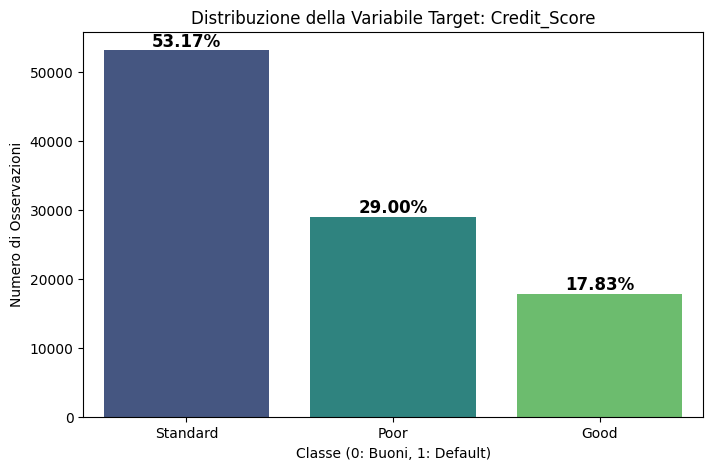


Rapporto tra classe maggioritaria e minoritaria: 2.98:1

Il dataset è bilanciato o moderatamente sbilanciato.


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analisi_target(df, target_col):
    """
    Analizza la distribuzione della variabile target e valuta lo sbilanciamento.
    """
    print(f"=== 2. ANALISI DELLA TARGET VARIABLE: {target_col} ===")
    
    # Calcolo frequenze assolute e relative
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100
    
    dist_df = pd.DataFrame({
        'Conteggio': counts,
        'Percentuale (%)': percentages
    })
    
    print(dist_df)
    print("-" * 40)

    # Visualizzazione
    plt.figure(figsize=(8, 5))
    sns.barplot(x=counts.index, y=counts.values, palette='viridis')
    plt.title(f'Distribuzione della Variabile Target: {target_col}')
    plt.xlabel('Classe (0: Buoni, 1: Default)')
    plt.ylabel('Numero di Osservazioni')
    
    # Aggiunta etichette con percentuali sopra le barre
    for i, p in enumerate(percentages):
        plt.text(i, counts.iloc[i], f'{p:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.show()

    # Valutazione strategica
    ratio = counts.max() / counts.min()
    print(f"\nRapporto tra classe maggioritaria e minoritaria: {ratio:.2f}:1")
    
    if ratio > 4:
        print("\nATTENZIONE: Il dataset è fortemente sbilanciato.")
        print("Strategie consigliate:")
        print("- Metriche: Non usare l'Accuracy. Usa Precision-Recall AUC, F1-Score o Log-Loss.")
        print("- Modelli: Usa algoritmi che gestiscono i pesi (es. 'class_weight' in Random Forest o XGBoost).")
        print("- Resampling: Valuta tecniche come SMOTE (oversampling) o Under-sampling.")
    else:
        print("\nIl dataset è bilanciato o moderatamente sbilanciato.")

# Esempio di utilizzo (sostituisci 'SeriousDlqin2yrs' con il nome della tua colonna target)
analisi_target(df_train, 'Credit_Score')

=== 3.1 STATISTICHE DESCRITTIVE ===
                                 mean          50%          std         min  \
Monthly_Inhand_Salary     4194.170850  3093.745000  3183.686167  303.645417   
Num_Bank_Accounts           17.091280     6.000000   117.404834   -1.000000   
Num_Credit_Card             22.474430     5.000000   129.057410    0.000000   
Interest_Rate               72.466040    13.000000   466.422621    1.000000   
Delay_from_due_date         21.068780    18.000000    14.860104   -5.000000   
Num_Credit_Inquiries        27.754251     6.000000   193.177339    0.000000   
Credit_Utilization_Ratio    32.285173    32.305784     5.116875   20.000000   
Total_EMI_per_month       1403.118217    69.249473  8306.041270    0.000000   

                                   max   skewness  
Monthly_Inhand_Salary     15204.633333   1.127252  
Num_Bank_Accounts          1798.000000  11.202314  
Num_Credit_Card            1499.000000   8.457890  
Interest_Rate              5797.000000   9.0

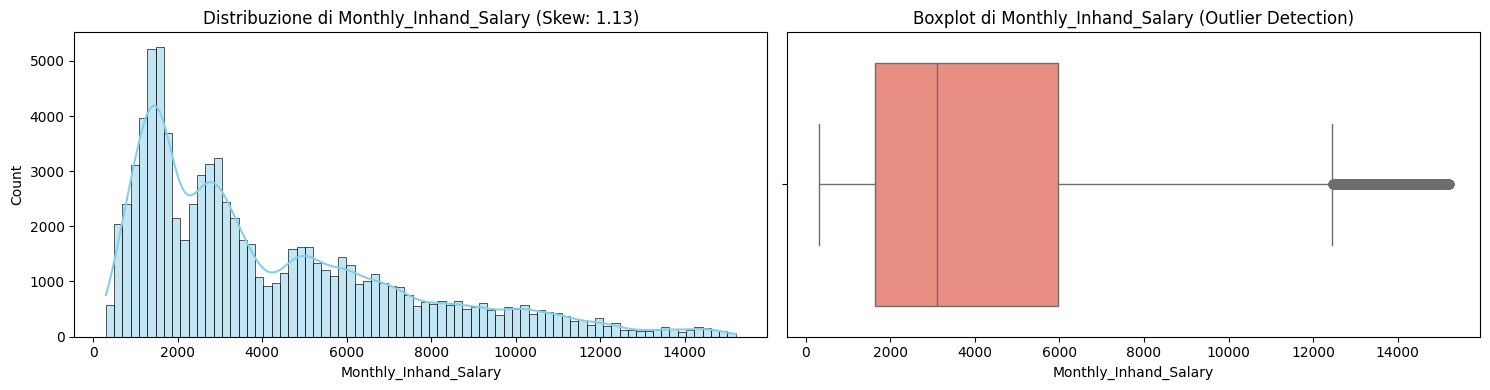

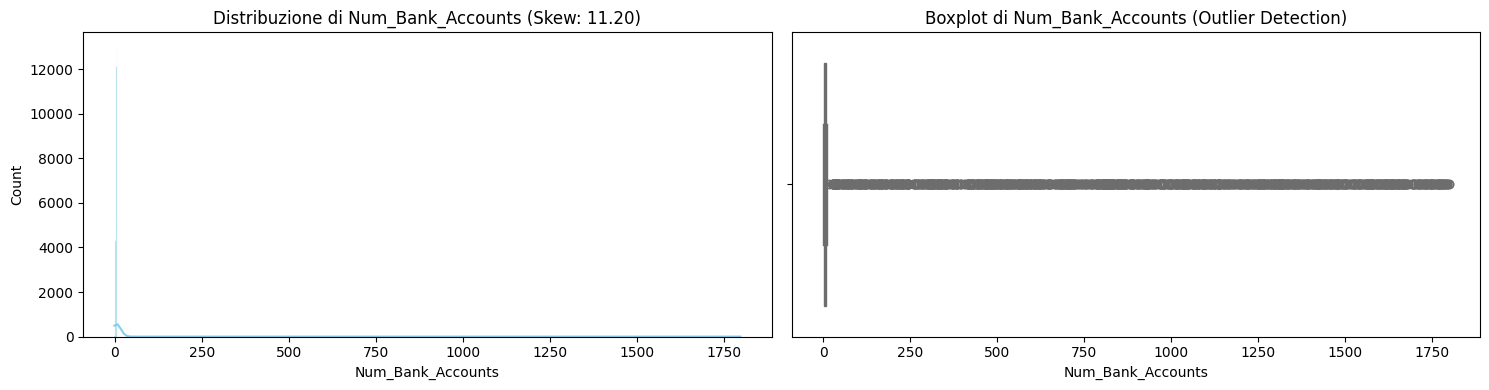

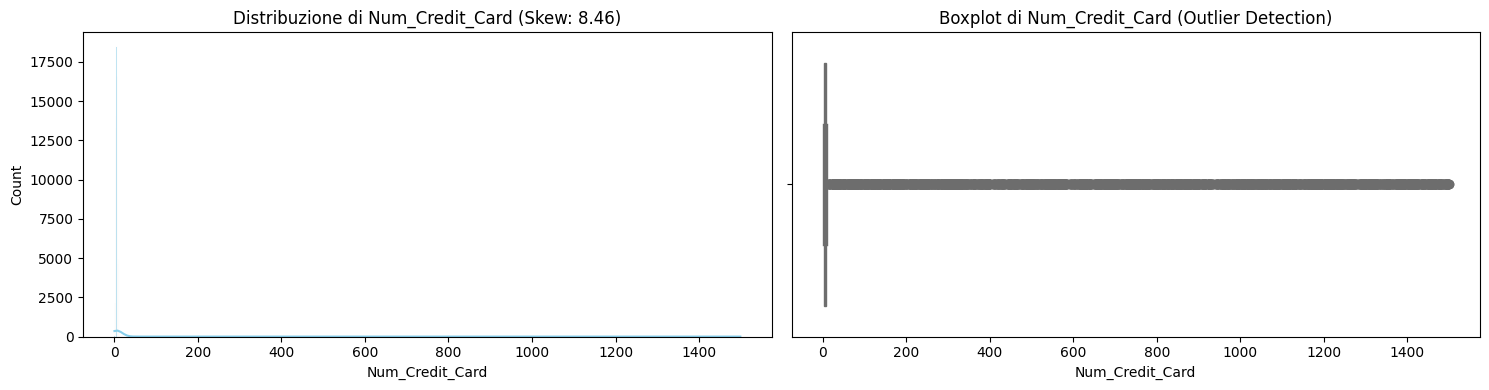

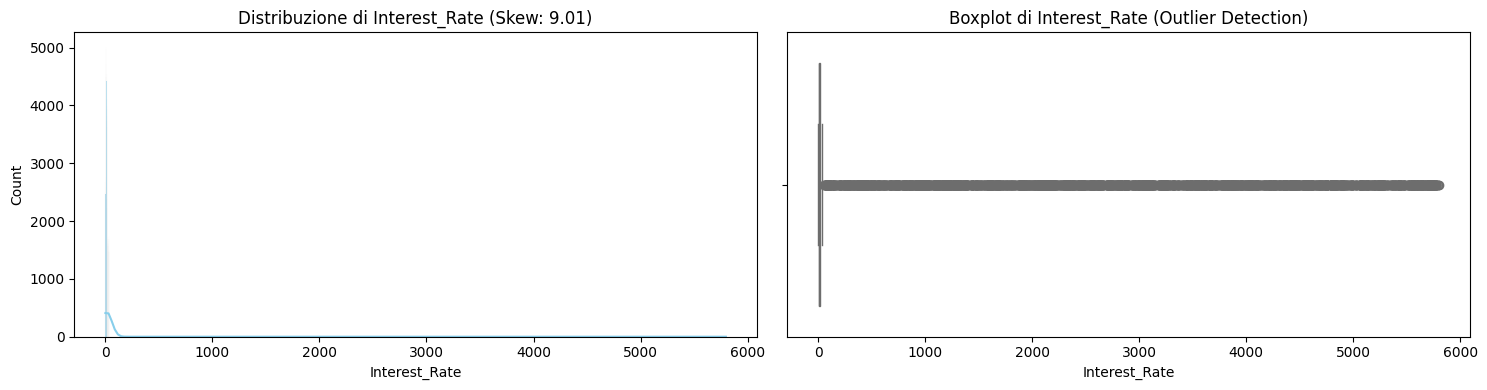

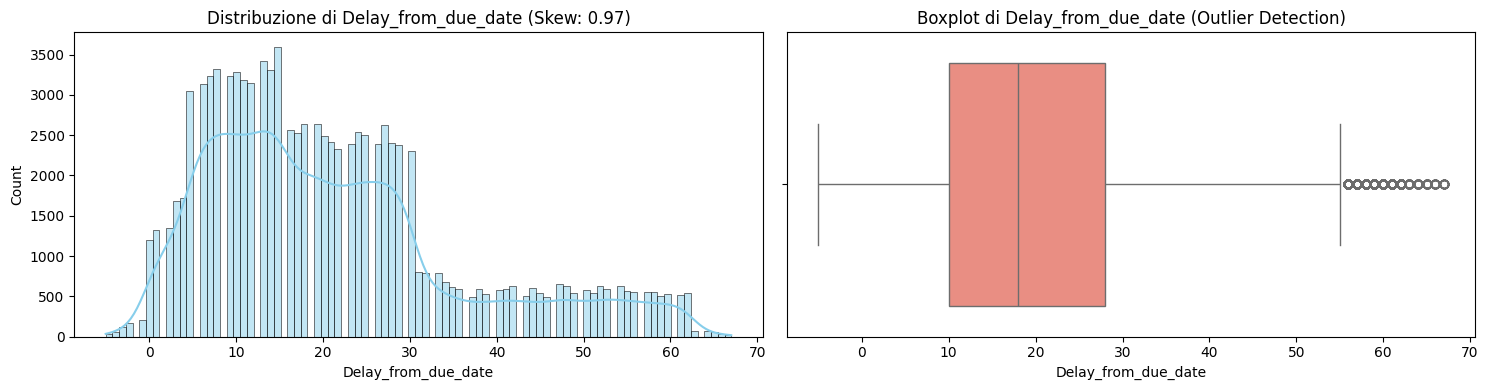

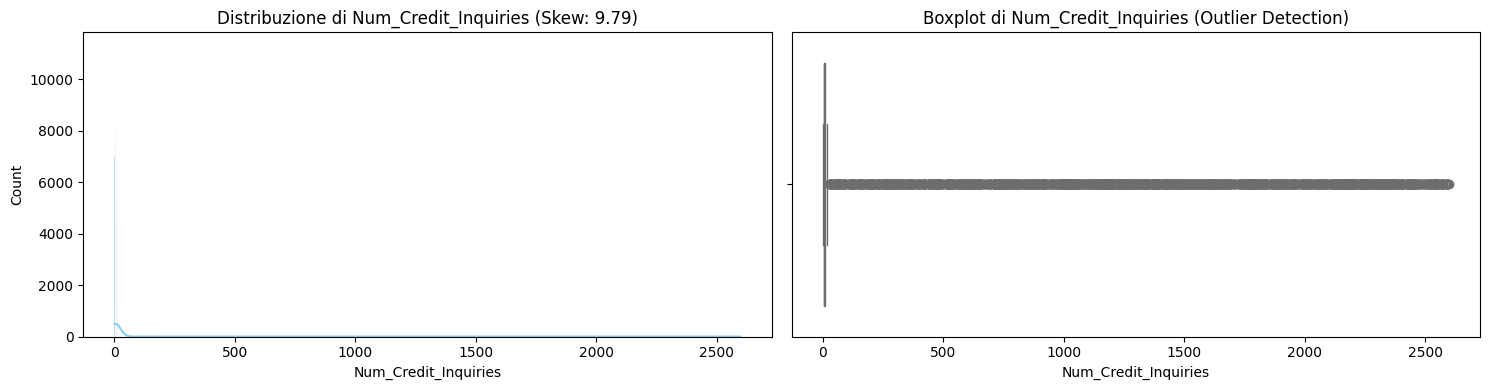

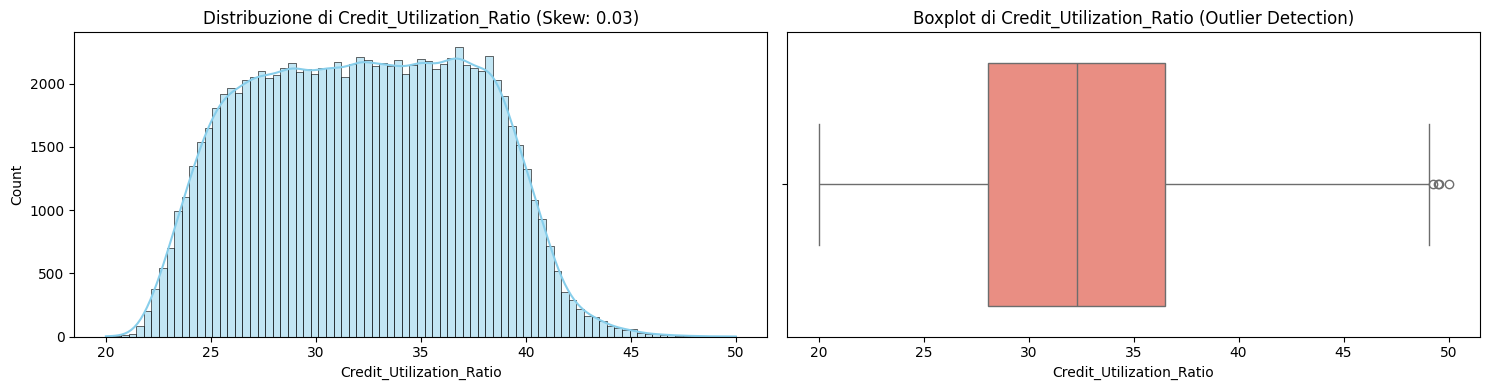

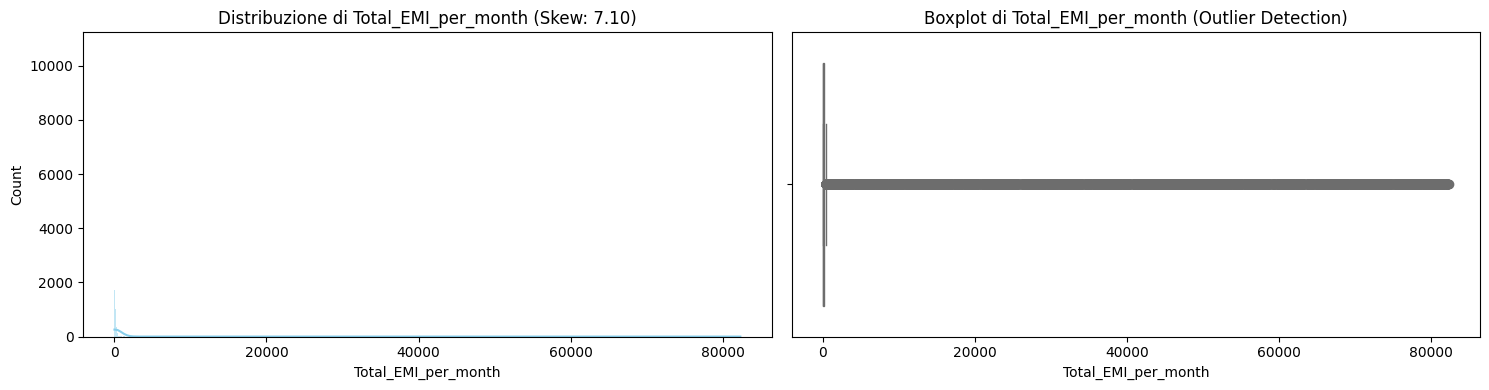

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew

def analisi_univariata(df):
    """
    Esegue l'analisi statistica e visuale delle variabili numeriche.
    """
    # Selezioniamo solo le colonne numeriche
    df_num = df.select_dtypes(include=['float64', 'int64'])
    
    print("=== 3.1 STATISTICHE DESCRITTIVE ===")
    # Calcolo statistiche principali e aggiunta della Skewness
    stats = df_num.describe().T
    stats['skewness'] = df_num.apply(lambda x: skew(x.dropna()))
    print(stats[['mean', '50%', 'std', 'min', 'max', 'skewness']])
    print("-" * 40)

    print("\n=== 3.2 VISUALIZZAZIONE DISTRIBUZIONI E OUTLIER ===")
    # Creiamo un ciclo per graficare ogni variabile
    for col in df_num.columns:
        fig, axes = plt.subplots(1, 2, figsize=(15, 4))
        
        # Istogramma + KDE per la distribuzione e Skewness
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Distribuzione di {col} (Skew: {df[col].skew():.2f})')
        
        # Boxplot per individuare gli outlier
        sns.boxplot(x=df[col], ax=axes[1], color='salmon')
        axes[1].set_title(f'Boxplot di {col} (Outlier Detection)')
        
        plt.tight_layout()
        plt.show()

# Utilizzo:
analisi_univariata(df_train)

=== 4.1 HEATMAP DI CORRELAZIONE (Pearson) ===


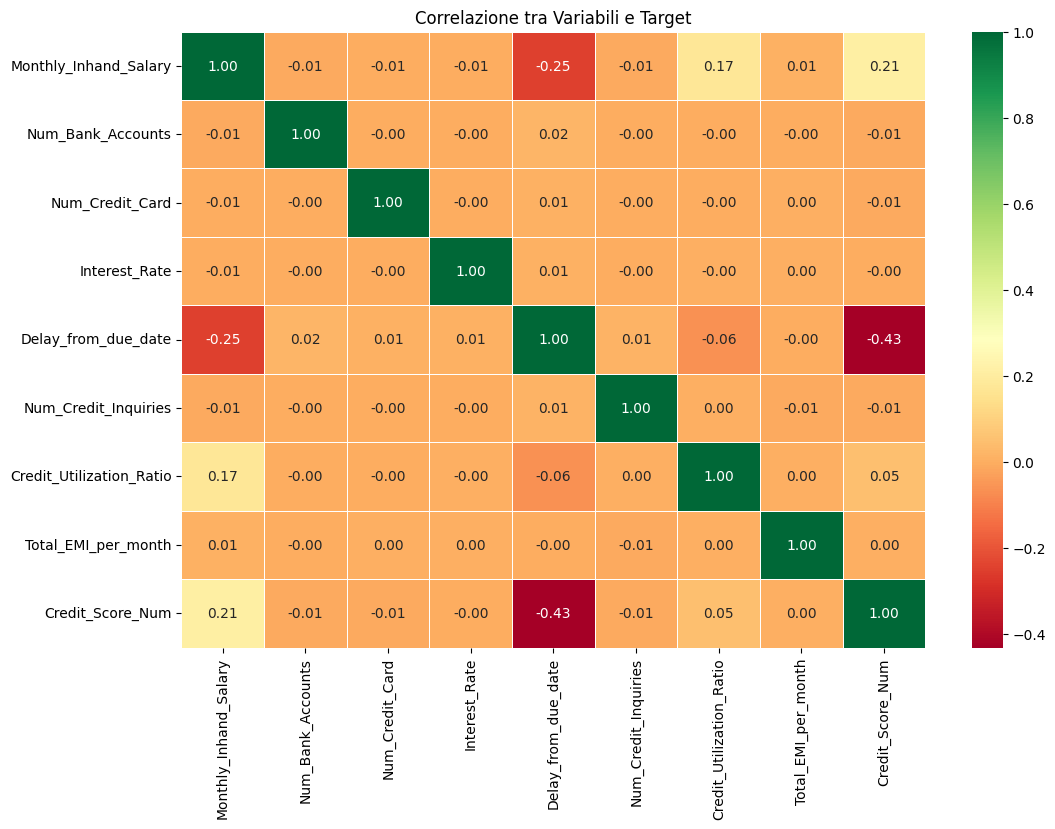


=== 4.2 CONFRONTO DISTRIBUZIONI (Boxplot per Target) ===


C:\Users\mbagn\AppData\Local\Temp\ipykernel_29772\2854776773.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, order=['Poor', 'Standard', 'Good'], palette='Set2')


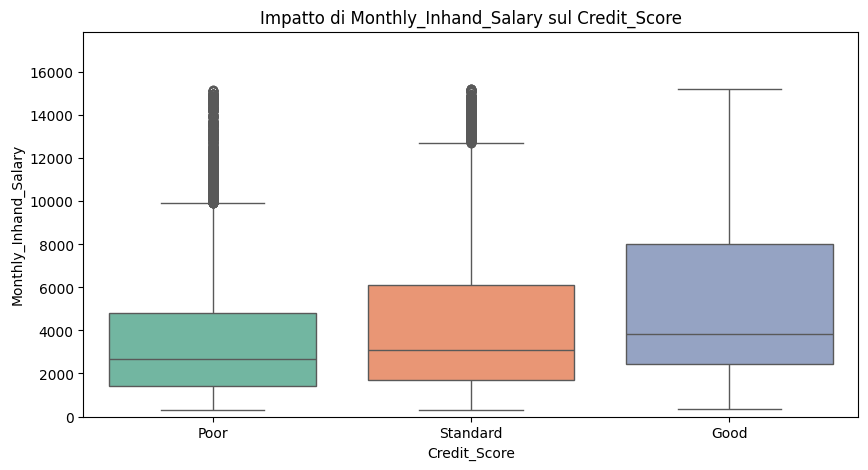

C:\Users\mbagn\AppData\Local\Temp\ipykernel_29772\2854776773.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, order=['Poor', 'Standard', 'Good'], palette='Set2')


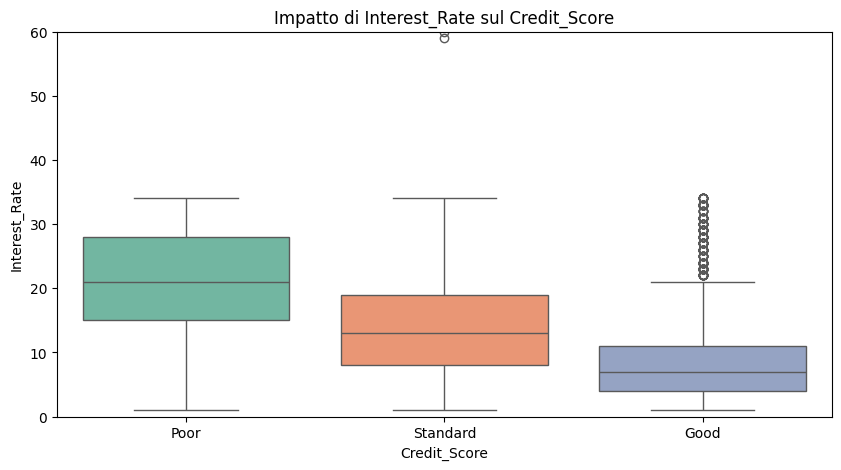

C:\Users\mbagn\AppData\Local\Temp\ipykernel_29772\2854776773.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, order=['Poor', 'Standard', 'Good'], palette='Set2')


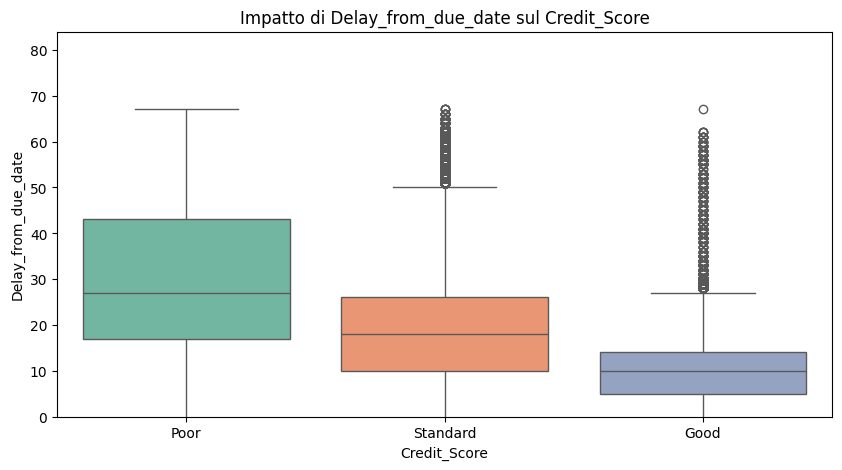

C:\Users\mbagn\AppData\Local\Temp\ipykernel_29772\2854776773.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, order=['Poor', 'Standard', 'Good'], palette='Set2')


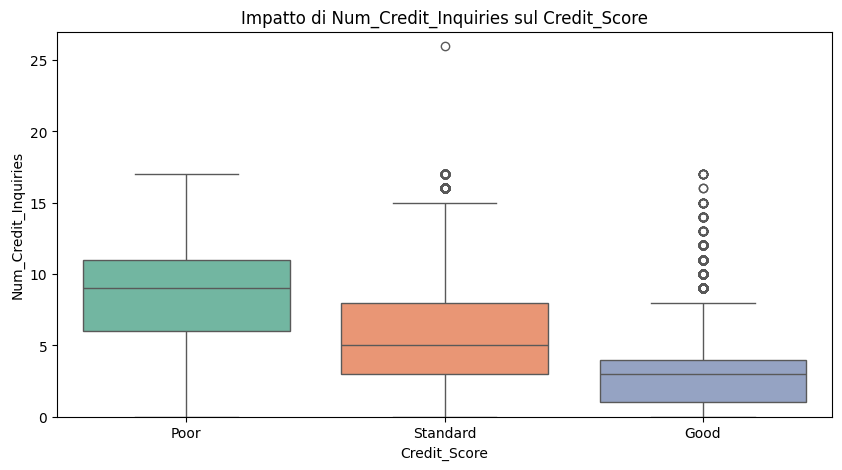


=== 4.3 ANALISI DELLE CATEGORIE (Esempio: Occupation) ===


<Figure size 1200x600 with 0 Axes>

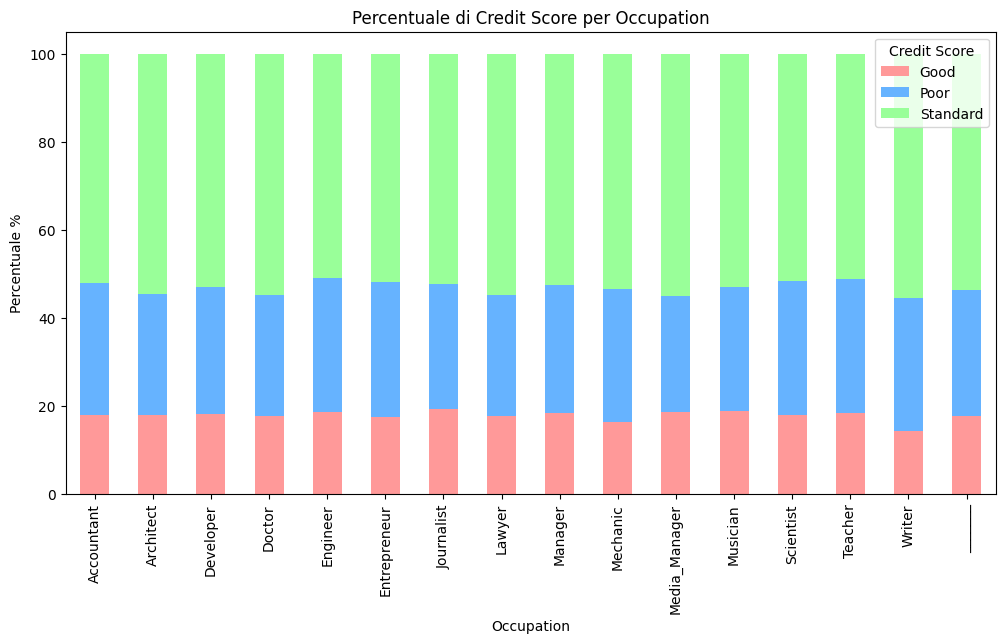

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def analisi_bivariata(df, target_col):
    """
    Analizza la relazione tra le feature e il Credit_Score.
    """
    # 1. Mappatura numerica del target per la correlazione
    # Mappiamo in ordine logico: Poor=0, Standard=1, Good=2
    target_map = {'Poor': 0, 'Standard': 1, 'Good': 2}
    df_corr = df.copy()
    df_corr[target_col + '_Num'] = df_corr[target_col].map(target_map)

    print(f"=== 4.1 HEATMAP DI CORRELAZIONE (Pearson) ===")
    plt.figure(figsize=(12, 8))
    # Calcoliamo la correlazione includendo il target mappato
    numeric_cols = df_corr.select_dtypes(include=['float64', 'int64']).columns
    correlation_matrix = df_corr[numeric_cols].corr()
    
    sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
    plt.title("Correlazione tra Variabili e Target")
    plt.show()

    print("\n=== 4.2 CONFRONTO DISTRIBUZIONI (Boxplot per Target) ===")
    # Selezioniamo alcune variabili chiave da confrontare
    key_features = ['Monthly_Inhand_Salary', 'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries']
    
    for col in key_features:
        plt.figure(figsize=(10, 5))
        # Usiamo il boxplot per vedere come variano i quartili tra le classi
        sns.boxplot(x=target_col, y=col, data=df, order=['Poor', 'Standard', 'Good'], palette='Set2')
        plt.title(f'Impatto di {col} sul {target_col}')
        # Limiti per gestire gli outlier estremi che abbiamo visto nel punto 3.1
        # Questo serve per rendere il grafico leggibile
        q3 = df[col].quantile(0.75)
        plt.ylim(0, q3 * 3) 
        plt.show()

    print("\n=== 4.3 ANALISI DELLE CATEGORIE (Esempio: Occupation) ===")
    # Se hai una colonna categorica come 'Occupation' o 'Payment_Behaviour'
    cat_col = 'Occupation' # Sostituisci con una colonna esistente nel tuo csv
    if cat_col in df.columns:
        plt.figure(figsize=(12, 6))
        # Creiamo una tabella di contingenza normalizzata
        ct = pd.crosstab(df[cat_col], df[target_col], normalize='index') * 100
        ct.plot(kind='bar', stacked=True, figsize=(12,6), color=['#ff9999','#66b3ff','#99ff99'])
        plt.title(f'Percentuale di Credit Score per {cat_col}')
        plt.ylabel('Percentuale %')
        plt.legend(title='Credit Score')
        plt.show()

# Utilizzo:
analisi_bivariata(df_train, 'Credit_Score')

CONTESTO: abbiamo dei valori che non rispettano gli standard

PROBLEMI: 

Skewness elevata

=== 3.1 STATISTICHE DESCRITTIVE ===                                 mean          50%          std         min  \Monthly_Inhand_Salary     4194.170850  3093.745000  3183.686167  303.645417   Num_Bank_Accounts           17.091280     6.000000   117.404834   -1.000000   Num_Credit_Card             22.474430     5.000000   129.057410    0.000000   Interest_Rate               72.466040    13.000000   466.422621    1.000000   Delay_from_due_date         21.068780    18.000000    14.860104   -5.000000   Num_Credit_Inquiries        27.754251     6.000000   193.177339    0.000000   Credit_Utilization_Ratio    32.285173    32.305784     5.116875   20.000000   Total_EMI_per_month       1403.118217    69.249473  8306.041270    0.000000                                      max   skewness  Monthly_Inhand_Salary     15204.633333   1.127252  Num_Bank_Accounts          1798.000000  11.202314  Num_Credit_Card            1499.000000   8.457890  Interest_Rate              5797.000000   9.005880  Delay_from_due_date          67.000000   0.966380  Num_Credit_Inquiries       2597.000000   9.786096  Credit_Utilization_Ratio     50.000000   0.028616  Total_EMI_per_month       82331.000000   7.102418  ----------------------------------------

Valori nulli

=== 2. ANALISI DEI VALORI MANCANTI ===                         Valori Mancanti  Percentuale (%)Monthly_Inhand_Salary              15002           15.002Type_of_Loan                       11408           11.408Name                                9985            9.985Credit_History_Age                  9030            9.030Num_of_Delayed_Payment              7002            7.002Amount_invested_monthly             4479            4.479Num_Credit_Inquiries                1965            1.965Monthly_Balance                     1200            1.200

target sbilanciato

=== 2. ANALISI DELLA TARGET VARIABLE: Credit_Score ===              Conteggio  Percentuale (%)Credit_Score                            Standard          53174           53.174Poor              28998           28.998Good              17828           17.828


Sei Luigi, esperto di machine learning con 10 anni di esperienza come leader di un team di sviluppo di xgboost, e successivamente professore di harvard lato AI, come risolveresti questi problemi in modo professionale?

Piacere di conoscerti. Sono Luigi. Dopo anni passati a ottimizzare le euristiche di split in XGBoost e a insegnare ad Harvard come i modelli interpretano il mondo, posso dirti una cosa fondamentale: un algoritmo potente su dati sporchi è solo un modo più veloce per ottenere risultati sbagliati.

Il tuo dataset di Credit Scoring ha "rumore" tipico delle competizioni Kaggle, ma con segnali di errori strutturali profondi. Ecco come affronteremmo la questione nel mio team, muovendoci tra pragmatismo ingegneristico e rigore accademico.

1. Outlier e Skewness: La "Potatura" Scientifica
I valori che hai riportato (es. 1798 conti bancari o 5797% di interesse) non sono "dati estremi", sono errori di inserimento. I modelli a base d'albero come XGBoost sono robusti, ma outlier così massivi frammentano lo spazio delle feature inutilmente.

La Soluzione Prof: Winsorization (Capping). Invece di eliminare le righe, limitiamo i valori al 1° e 99° percentile. Per variabili come Interest_Rate, userei un "cap" basato sulla logica di dominio (es. non può superare il 100%).

Trattamento Skewness: Per variabili con skewness > 1 (come Monthly_Inhand_Salary), applicherei una trasformazione Logaritmica o Yeo-Johnson. Questo rende la distribuzione più "campanulare", aiutando il modello a trovare split migliori.

Python

import numpy as np

# Esempio di Capping e Log-Transform
def handle_extremes(df, col):
    upper_limit = df[col].quantile(0.99)
    df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
    # Se la skewness è ancora alta:
    df[col] = np.log1p(df[col]) 
    return df
2. Missing Values: Oltre l'Imputazione Semplice
Hai il 15% di missing su Monthly_Inhand_Salary. Nel Credit Scoring, il fatto che un dato manchi è esso stesso un'informazione (Missingness as a Feature).

La Soluzione Prof: Group-based Imputation + Binary Flags. Non usare la media globale. Se un utente è un "Manager", il suo stipendio mancante va imputato con la mediana dei "Manager".

XGBoost Lead Tip: XGBoost gestisce i NaN internamente (apprende la direzione di default per i missing), ma per variabili categoriche come Type_of_Loan, la strategia migliore è creare una nuova categoria "Unknown".

Python

# Imputazione intelligente per lo stipendio
df['Monthly_Inhand_Salary'] = df.groupby('Occupation')['Monthly_Inhand_Salary']\
                                .transform(lambda x: x.fillna(x.median()))

# Creazione di una colonna "Missing_Flag"
df['Salary_Is_Missing'] = df['Monthly_Inhand_Salary'].isnull().astype(int)
3. Target Imbalance: Cost-Sensitive Learning
Il tuo target ha una gerarchia: Good (18%), Standard (53%), Poor (29%). Non è uno sbilanciamento estremo, ma è sufficiente a rendere il modello "pigro" verso la classe Good.

La Soluzione Prof: Class Weights. Ad Harvard insegniamo che lo SMOTE (oversampling sintetico) può creare artefatti pericolosi nel credito. Preferisco dire a XGBoost di dare più importanza agli errori commessi sulla classe minoritaria tramite il parametro sample_weight o definendo i pesi delle classi.

Metrica di Riferimento: Dimentica l'Accuracy. Useremo il Macro-F1 Score o la Log-Loss pesata. Dobbiamo assicurarci che il richiamo (recall) per la classe Poor sia altissimo: la banca teme chi non paga più di quanto ami chi è eccellente.

Il mio Piano d'Azione consigliato:
Cleaning Hard: Filtra i valori impossibili (es. età < 18 o > 100, Num_Bank_Accounts > 20).

Feature Engineering: Crea una feature Debt_to_Income_Ratio usando Total_EMI_per_month e Monthly_Inhand_Salary. È il cuore pulsante del rischio creditizio.

Encoding: Usa il Target Encoding per le variabili categoriche ad alta cardinalità (come Occupation), ma con cross-validation per evitare l'overfitting.

Model: XGBoost con monotonic_constraints. Ad esempio, all'aumentare di Delay_from_due_date, la probabilità di Poor deve aumentare. Questo rende il modello robusto e spiegabile ai regolatori bancari.

Luigi's Final Thought: "Il codice si scrive in un pomeriggio, la comprensione della qualità del dato richiede giorni. Non correre al modello prima di aver 'curato' i tuoi dati."

Vuoi che generiamo insieme il codice per la Feature Engineering specifica per il credito?